In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gps_sim

In [20]:
f_s = 10.23e6
N = 2**10
x = gps_sim.generate_gps(f_s, N, 3, 100e3, snr_db=None)

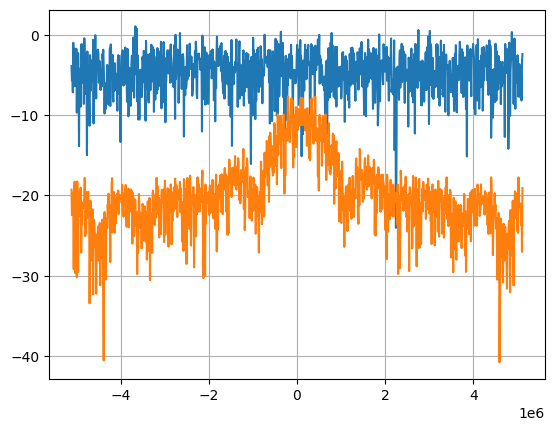

In [35]:
X = np.fft.fftshift(np.fft.fft(x)) / N
X = 10*np.log10(np.abs(X))
f = np.linspace(-f_s/2, f_s/2, N)

cn0 = -130 + 174
cn = cn0 - 10*np.log10(f_s/2)
amplitude = 10 ** (-cn/20) # 20 because amplitude
noise = amplitude * (np.random.randn(N) + 1j*np.random.randn(N)) / np.sqrt(2)
# samples = samples + noise
Y = np.fft.fftshift(np.fft.fft(noise)) / N
Y = 10*np.log10(np.abs(Y))

plt.plot(f, Y)
plt.plot(f, X)
plt.grid()

In [25]:
print(np.var(x)) # -130 dBm
print(np.var(noise)) # -174 dBm/Hz
print(10*np.log10(np.var(x) / np.var(noise)))

0.99053586
96.28026031673235
-19.876670551271225


In [ ]:
f_s = 2.6e6
n = int(f_s*2)
sv = 1
doppler = 10e3
doppler2 = 100
code_phase = 0
signal_power = -130

samples = gps_sim.generate_gps(f_s, n, sv, doppler, doppler2, code_phase, signal_power)

samples.tofile()